# Image Collection for Fine-Tuning Dataset

**Purpose**: Collect ~120 Singapore nadir aerial images across 9 scene types for QLoRA fine-tuning of Qwen2.5-VL-7B.

**Strategy**:
- All images sourced via Google Maps Static API (automated)
- Heavy weighting toward HDB estates (widest vocabulary gap from benchmark)
- Paired roadmap reference images for annotation quality

**Target**: ~120 annotated nadir images for QLoRA fine-tuning (70/15/15 train/val/test split).

**Setup**: Set the `GMAPS_API_KEY` environment variable before running (e.g. `export GMAPS_API_KEY=...` or add to `.env`).

In [1]:
# Dependencies: pip install Pillow matplotlib pandas requests
# Or: uv sync (reads from pyproject.toml)

In [3]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from PIL import Image

# --------------- API Key ---------------
API_KEY = os.environ.get("GMAPS_API_KEY")
if not API_KEY:
    raise RuntimeError(
        "GMAPS_API_KEY not set. Export it first:\n"
        "  export GMAPS_API_KEY='your-key-here'  (Linux/Mac)\n"
        "  set GMAPS_API_KEY=your-key-here       (Windows cmd)\n"
        "  $env:GMAPS_API_KEY='your-key-here'    (PowerShell)"
    )

# --------------- Paths (project-relative) ---------------
ROOT = Path("..").resolve()  # notebook is in notebooks/
NADIR_DIR = ROOT / "images" / "nadir"
REFERENCE_DIR = ROOT / "images" / "reference"
DATA_DIR = ROOT / "data"
for d in [NADIR_DIR, REFERENCE_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root:  {ROOT}")
print(f"Nadir dir:     {NADIR_DIR}")
print(f"Reference dir: {REFERENCE_DIR}")
print("Setup complete.")

Project root:  C:\Users\kaiho\Downloads\Python\vlm-scene-analyser
Nadir dir:     C:\Users\kaiho\Downloads\Python\vlm-scene-analyser\images\nadir
Reference dir: C:\Users\kaiho\Downloads\Python\vlm-scene-analyser\images\reference
Setup complete.


In [ ]:
# --------------- Singapore Coordinate List ---------------
# Format: (name, lat, lon, scene_type, zoom)
#
# Coordinates approximate — verify downloaded images and adjust if needed.
# At zoom 18 / scale=2, each image covers ~300m x 300m.
# At zoom 17, ~600m x 600m. At zoom 16, ~1200m x 1200m.

SG_LOCATIONS = [
    # ============================================================
    # HDB ESTATES (27 locations) — highest priority
    # 80% of SG population lives in HDB. Zero baseline vocabulary.
    # Mix of generations: 1970s slab blocks to 2020s point blocks.
    # ============================================================
    ("toa_payoh",           1.3354, 103.8486, "hdb", 18),
    ("tampines",            1.3550, 103.9534, "hdb", 18),
    ("punggol",             1.4047, 103.8987, "hdb", 18),
    ("ang_mo_kio",          1.3688, 103.8544, "hdb", 18),
    ("ang_mo_kio_2",        1.3663, 103.8478, "hdb", 18),
    ("bukit_batok",         1.3499, 103.7582, "hdb", 18),
    ("jurong_east",         1.3375, 103.7388, "hdb", 18),
    ("clementi",            1.3141, 103.7677, "hdb", 18),
    ("queenstown",          1.2939, 103.8039, "hdb", 18),
    ("bedok",               1.3327, 103.9259, "hdb", 18),
    ("woodlands_hdb",       1.4408, 103.7970, "hdb", 18),
    ("yishun",              1.4271, 103.8519, "hdb", 18),
    ("sengkang",            1.3873, 103.8941, "hdb", 18),
    ("hougang",             1.3707, 103.8804, "hdb", 18),
    ("pasir_ris",           1.3677, 103.9548, "hdb", 18),
    ("serangoon_north",     1.3736, 103.8718, "hdb", 18),
    ("choa_chu_kang",       1.3822, 103.7417, "hdb", 18),
    ("jurong_west",         1.3516, 103.7242, "hdb", 18),
    ("bishan",              1.3576, 103.8472, "hdb", 18),
    ("bukit_merah",         1.2798, 103.8262, "hdb", 18),
    ("bukit_panjang",       1.3858, 103.7702, "hdb", 18),
    ("sembawang",           1.4484, 103.8166, "hdb", 18),
    ("dawson",              1.2951, 103.8111, "hdb", 18),
    ("marine_parade",       1.3043, 103.9143, "hdb", 18),
    ("whampoa",             1.3266, 103.8591, "hdb", 18),
    ("dover_hdb",           1.3078, 103.7840, "hdb", 18),
    ("toh_guan",            1.3400, 103.7450, "hdb", 17),

    # ============================================================
    # CBD / COMMERCIAL (11 locations)
    # ============================================================
    ("marina_bay",          1.2821, 103.8576, "commercial", 17),
    ("raffles_place",       1.2840, 103.8514, "commercial", 18),
    ("orchard",             1.3048, 103.8318, "commercial", 18),
    ("tanjong_pagar",       1.2760, 103.8460, "commercial", 18),
    ("suntec_city",         1.2945, 103.8580, "commercial", 18),
    ("robinson_road",       1.2800, 103.8490, "commercial", 18),
    ("beach_road",          1.2979, 103.8586, "commercial", 17),
    ("tai_seng",            1.3379, 103.891, "commercial", 17),
    ("changi_biz_park",     1.335, 103.9653, "commercial", 17),
    ("mapletree_biz_city",  1.2746, 103.799, "commercial", 18),
    ("one_north",           1.2990, 103.7870, "commercial", 18),
    ("jalan_besar",         1.3100, 103.8570, "commercial", 18),
    ("chinatown",           1.2837, 103.8437, "commercial", 18),
    ("kampong_glam",        1.3017, 103.8594, "commercial", 18),
    ("little_india",        1.3070, 103.8520, "commercial", 18),
    ("bugis",               1.3000, 103.8555, "commercial", 18),
    ("harbourfront",        1.2650, 103.8220, "commercial", 18),
    ("paya_lebar_central",  1.3180, 103.8930, "commercial", 18),

    # ============================================================
    # PORT / MARITIME (10 locations)
    # ============================================================
    ("psa_pp_t1",           1.2685, 103.7940, "port", 16),
    ("habourfront",         1.2621, 103.8187, "port", 17),
    ("jurong_port",         1.3035, 103.7242, "port", 17),
    ("keppel_terminal",     1.2630, 103.8320, "port", 16),
    ("sembawang_shipyard",  1.4656, 103.8275, "port", 16),
    ("west_coast_pier",     1.2926, 103.7622, "port", 17),
    ("tuas_port",           1.2524, 103.6145, "port", 15),
    ("marina_south_pier",   1.2700, 103.8630, "port", 17),
    ("pasir_panjang_wharf", 1.2750, 103.7800, "port", 16),
    ("tanjong_pagar_terminal", 1.267, 103.8463, "port", 16),

    # ============================================================
    # AIRPORT (5 locations)
    # ============================================================
    ("changi_t1_t2_t3",     1.3554, 103.9885, "airport", 16),
    ("seletar",             1.4167, 103.8675, "airport", 17),
    ("changi_t4",           1.3411, 103.9819, "airport", 16),
    ("changi_cargo",        1.3762, 103.9963, "airport", 16),
    ("paya_lebar_ab_north", 1.3687, 103.9161, "airport", 16),


    # ============================================================
    # INDUSTRIAL (13 locations)
    # ============================================================
    ("jurong_island",       1.2735, 103.7229, "industrial", 16),
    ("tuas",                1.3255, 103.645, "industrial", 16),
    ("pioneer",             1.3314, 103.7014, "industrial", 17),
    ("amk_industrial",      1.374, 103.8633, "industrial", 17),
    ("woodlands_industrial",1.4519, 103.7985, "industrial", 17),
    ("ubi",                 1.3311, 103.8939, "industrial", 17),
    ("defu_industrial",     1.3598, 103.8991, "industrial", 17),
    ("gul_circle",          1.3162, 103.6705, "industrial", 16),
    ("loyang_industrial",   1.3737, 103.9681, "industrial", 17),
    ("senoko",              1.4665, 103.8027, "industrial", 17),
    ("joo_koon",            1.3259, 103.6736, "industrial", 17),
    ("kallang_pudding",     1.3258, 103.8768, "industrial", 17),
    ("pulau_bukom",         1.2300, 103.7650, "industrial", 16),

    # ============================================================
    # PARKS / GREEN (9 locations)
    # ============================================================
    ("east_coast_park",     1.3003, 103.9121, "parks", 18),
    ("botanic_gardens",     1.3138, 103.8159, "parks", 17),
    ("macritchie",          1.3421, 103.8326, "parks", 18),
    ("gardens_by_bay",      1.2816, 103.8636, "parks", 17),
    ("bishan_amk_park",     1.3614, 103.8479, "parks", 18),
    ("jurong_lake_gardens", 1.3380, 103.7290, "parks", 17),
    ("labrador_park",       1.2660, 103.8020, "parks", 17),
    ("pasir_ris_park",      1.3808, 103.9511, "parks", 17),
    ("kent_ridge_park",     1.285, 103.79, "parks", 18),

    # ============================================================
    # CONSTRUCTION / DEVELOPMENT (7 locations)
    # ============================================================
    ("tengah",              1.3611, 103.7146, "construction", 16),
    ("bayshore",            1.3161, 103.949, "construction", 17),
    ("woodlands_north_dev", 1.4487, 103.7864, "construction", 17),
    ("lim_chu_kang",        1.4291, 103.7114, "construction", 17),
    ("lentor",              1.385, 103.8337, "construction", 17),
    ("springleaf",          1.3960, 103.8176, "construction", 18),
    ("mandai_dev",          1.4043, 103.7858, "construction", 18),

    # ============================================================
    # TRANSPORT INFRASTRUCTURE (6 locations)
    # ============================================================
    ("bishan_depot",        1.3554, 103.8543, "transport", 17),
    ("woodlands_ckpt",      1.4491, 103.7700, "transport", 18),
    ("ulu_pandan_depot",    1.3328, 103.7605, "transport", 18),
    ("kranji_mrt",          1.4253, 103.762, "transport", 18),
    ("sengkang_depot",      1.388, 103.8851, "transport", 18),
    ("changi_depot",        1.3276, 103.9588, "transport", 17),

    # ============================================================
    # MIXED USE (14 locations)
    # ============================================================

    ("tiong_bahru",         1.2860, 103.8280, "mixed", 18),
    ("holland_village",     1.3110, 103.7960, "mixed", 18),
    ("balestier",           1.3250, 103.8520, "mixed", 18),
    ("katong",              1.3050, 103.9030, "mixed", 18),
    ("dempsey",             1.3050, 103.8100, "mixed", 18),
    ("jurong_lake_district",1.3320, 103.7380, "mixed", 17),
    ("marine_parade_vjc",   1.3059, 103.9198, "mixed", 17),
    ("geylang",             1.3170, 103.8880, "mixed", 18),
    ("alexandra",           1.2883, 103.8058, "mixed", 18),
    ("novena",              1.3200, 103.8440, "mixed", 18),
    ("west_coast_park",     1.2890, 103.7715, "mixed", 17),
    ("je_interchange",      1.3334, 103.7422, "mixed", 18),
    ("toa_payoh_interchange", 1.3324, 103.8474, "mixed", 18),
    ("pie_cte",             1.3305, 103.8624, "mixed", 17),
]

# --------------- Summary ---------------
from collections import Counter

print(f"Total locations: {len(SG_LOCATIONS)}")
print()

scene_counts = Counter(loc[3] for loc in SG_LOCATIONS)
print(f"{'Scene Type':<15} {'Count':>6}")
print("-" * 23)
for stype in sorted(scene_counts.keys()):
    print(f"{stype:<15} {scene_counts[stype]:>6}")
print("-" * 23)
print(f"{'TOTAL':<15} {sum(scene_counts.values()):>6}")

Total locations: 109

Scene Type       Count
-----------------------
airport              5
commercial          18
construction         7
hdb                 27
industrial          13
mixed               14
parks                9
port                10
transport            6
-----------------------
TOTAL              109


In [10]:
# --------------- Download Nadir Images via Google Maps Static API ---------------

STATIC_API_URL = "https://maps.googleapis.com/maps/api/staticmap"

downloaded = []
failed = []
skipped = []

for name, lat, lon, scene_type, zoom in SG_LOCATIONS:
    filename = f"nadir_{scene_type}_{name}_{lat}_{lon}.jpg"
    filepath = NADIR_DIR / filename

    if filepath.exists():
        skipped.append(filename)
        downloaded.append((str(filepath), name, scene_type))
        continue

    params = {
        "center": f"{lat},{lon}",
        "zoom": zoom,
        "size": "640x640",
        "scale": 2,  # -> 1280x1280 actual resolution
        "maptype": "satellite",
        "key": API_KEY,
    }

    for attempt in range(3):
        try:
            resp = requests.get(STATIC_API_URL, params=params, timeout=30)
            if resp.status_code == 200 and resp.headers.get("Content-Type", "").startswith("image"):
                filepath.write_bytes(resp.content)
                downloaded.append((str(filepath), name, scene_type))
                print(f"  [OK]   {filename} ({len(resp.content) / 1024:.0f} KB)")
                break
            else:
                print(f"  [WARN] {filename} attempt {attempt+1}: HTTP {resp.status_code}")
        except requests.RequestException as e:
            print(f"  [ERR]  {filename} attempt {attempt+1}: {e}")
        time.sleep(1)
    else:
        print(f"  [FAIL] {filename} after 3 attempts")
        failed.append(filename)

print(f"\nDownloaded: {len(downloaded) - len(skipped)} new | Skipped: {len(skipped)} existing | Failed: {len(failed)}")
print(f"Total nadir images: {len(downloaded)}")

  [OK]   nadir_transport_woodlands_ckpt_1.4491_103.77.jpg (548 KB)

Downloaded: 1 new | Skipped: 108 existing | Failed: 0
Total nadir images: 109


In [11]:
# --------------- Download Roadmap Reference Images ---------------
# Street maps with POI labels, building names, road names — used as
# annotation reference to identify Singapore-specific landmarks.

ref_downloaded = []
ref_failed = []
ref_skipped = []

for name, lat, lon, scene_type, zoom in SG_LOCATIONS:
    filename = f"ref_{scene_type}_{name}_{lat}_{lon}.jpg"
    filepath = REFERENCE_DIR / filename

    if filepath.exists():
        ref_skipped.append(filename)
        ref_downloaded.append(str(filepath))
        continue

    params = {
        "center": f"{lat},{lon}",
        "zoom": zoom,
        "size": "640x640",
        "scale": 2,
        "maptype": "roadmap",
        "key": API_KEY,
    }

    for attempt in range(3):
        try:
            resp = requests.get(STATIC_API_URL, params=params, timeout=30)
            if resp.status_code == 200 and resp.headers.get("Content-Type", "").startswith("image"):
                filepath.write_bytes(resp.content)
                ref_downloaded.append(str(filepath))
                print(f"  [OK]   {filename} ({len(resp.content) / 1024:.0f} KB)")
                break
            else:
                print(f"  [WARN] {filename} attempt {attempt+1}: HTTP {resp.status_code}")
        except requests.RequestException as e:
            print(f"  [ERR]  {filename} attempt {attempt+1}: {e}")
        time.sleep(1)
    else:
        print(f"  [FAIL] {filename} after 3 attempts")
        ref_failed.append(filename)

print(f"\nDownloaded: {len(ref_downloaded) - len(ref_skipped)} new | Skipped: {len(ref_skipped)} existing | Failed: {len(ref_failed)}")
print(f"Total reference maps: {len(ref_downloaded)}")

  [OK]   ref_transport_woodlands_ckpt_1.4491_103.77.jpg (58 KB)

Downloaded: 1 new | Skipped: 108 existing | Failed: 0
Total reference maps: 109


In [ ]:
# --------------- Display Nadir Thumbnail Grid ---------------

n_cols = 8
n_rows = (len(downloaded) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 3 * n_rows))
axes = axes.flatten()

for i, (fpath, name, stype) in enumerate(downloaded):
    img = Image.open(fpath)
    axes[i].imshow(img)
    axes[i].set_title(f"{stype}/{name}", fontsize=6)
    axes[i].axis("off")
for i in range(len(downloaded), len(axes)):
    axes[i].axis("off")

plt.suptitle(f"Nadir Images ({len(downloaded)} total)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [70]:
# --------------- Build Image Manifest ---------------

all_images = []

for fpath, name, scene_type in downloaded:
    all_images.append({
        "image_path": fpath,
        "name": name,
        "scene_type": scene_type,
    })

manifest_df = pd.DataFrame(all_images)
print(f"Total images in manifest: {len(all_images)}")
print()
print("By scene type:")
print(manifest_df["scene_type"].value_counts().to_string())

Total images in manifest: 115

By scene type:
scene_type
hdb             26
industrial      15
cbd             14
mixed           14
parks           13
port            11
transport       10
construction     7
airport          5


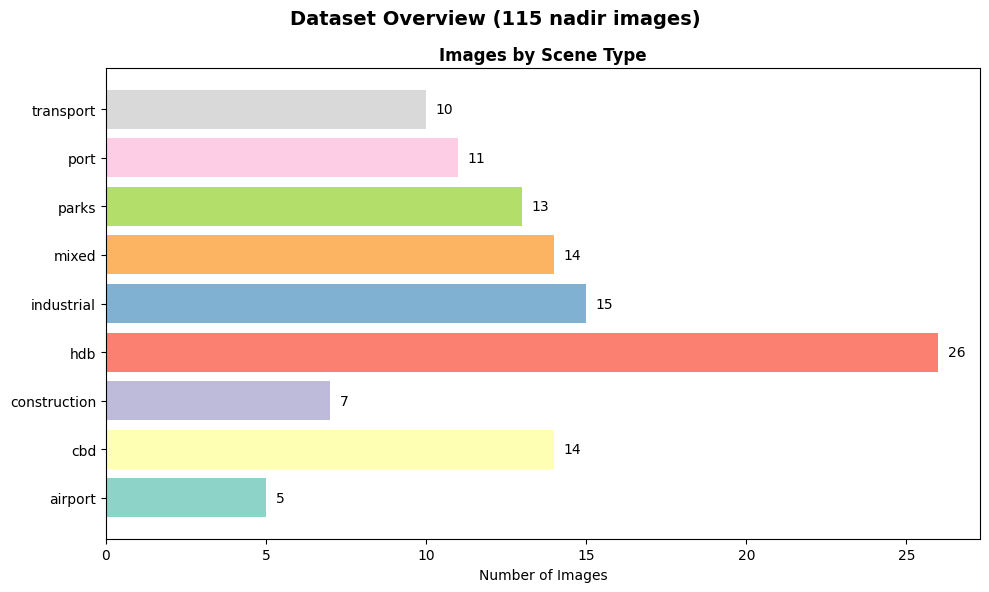

In [71]:
# --------------- Dataset Statistics ---------------

fig, ax = plt.subplots(figsize=(10, 6))

scene_data = manifest_df["scene_type"].value_counts().sort_index()
colors = plt.cm.Set3.colors[:len(scene_data)]
ax.barh(scene_data.index, scene_data.values, color=colors)
ax.set_xlabel("Number of Images")
ax.set_title("Images by Scene Type", fontweight="bold")
for i, v in enumerate(scene_data.values):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=10)

plt.suptitle(f"Dataset Overview ({len(all_images)} nadir images)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Next Step: Annotation

Images collected. Next steps:

1. **Review downloaded images** — check coordinates are centered correctly, exclude unusable images
2. **Annotate** each image with structured caption + analysis JSON using the dual-image prompt below
3. **Validate** annotations against schema
4. **Split** into 70/15/15 train/val/test stratified by scene type

### Target annotation schema (per image)

```json
{
  "caption": "Dense HDB estate in Toa Payoh viewed from above...",
  "scene_type": "residential_hdb",
  "analysis": {
    "objects": [{"type": "hdb_block", "count": 12}],
    "infrastructure": ["covered_walkway", "mrt_track"],
    "terrain": ["urban", "parkland"]
  }
}
```

# Annotation prompt v3 — Visual-First Grounding

```
Annotate nadir aerial images of Singapore for VLM fine-tuning. The model will ONLY see aerial pixels
at inference time — no maps, no street directories. Annotations must describe what is visually
inferrable from the satellite image alone.

# Core Principle

Name the STRUCTURE TYPE, not the INSTANCE. With 115 images we cannot exhaustively cover all MRT
stations, expressway sections, or interchanges. Naming specific instances trains memorisation, not
visual understanding.

  ✓ "MRT station"          ✗ "Bishan MRT station"
  ✓ "expressway"           ✗ "PIE"
  ✓ "bus interchange"      ✗ "Jurong East interchange"
  ✓ "shopping mall"        ✗ "Junction 8"

Geographic anchor: the estate/district name appears ONCE in the caption opener to set the scene.
It is NOT repeated on individual structures within the scene.

  ✓ "Dense HDB estate in Toa Payoh viewed from above. An MRT station is visible near the
     town centre."
  ✗ "Dense HDB estate in Toa Payoh. Toa Payoh MRT station visible."

The ONLY exception for naming specific structures: globally unique landmarks with unmistakable
visual signatures (Tier 2 below).

# Three-Tier Detail Framework

## Tier 1 — ALWAYS include (visually inferrable from pixels)

- Structural typology: HDB slab/point/cruciform blocks, shophouses, condos, warehouses,
  hawker centre roof structures, MRT station footprints
- Singapore vocabulary: covered walkway, hawker centre, MRT station, park connector
- Spatial patterns: grid layout, radial arrangement, linear estate, waterfront development
- Terrain/land use: water, parkland, urban, reclaimed land, forest reserve
- Infrastructure TYPES (generic): expressway, MRT track, MRT station, bus interchange,
  covered walkway, runway, taxiway, jetty, park connector
- Approximate counts (rounded to nearest 5 for >10): "~15 HDB blocks", "~200 containers"
- ONE geographic anchor per caption: estate/district name in the opening sentence only
  (e.g. "Dense HDB estate in Toa Payoh viewed from above."). Derived from the filename.

## Tier 2 — Include ONLY for globally unique visual signatures

Landmarks where the structure itself is unmistakable — no other building on Earth has that shape.
The model learns a genuine visual-to-name mapping, not a memorised label:

- Marina Bay Sands (3-tower + SkyPark cantilever)
- ArtScience Museum (lotus form)
- Gardens by the Bay (Supertrees / Cloud Forest / Flower Dome)
- Esplanade (durian shell structure)
- Singapore Flyer (giant wheel)
- Jewel Changi Airport (toroidal glass dome)
- Pinnacle@Duxton (sky bridges connecting towers)

## Tier 3 — NEVER include (requires map knowledge)

- Exact block/building numbers: "Block 80A", "Terminal 3"
- Street names: "Lorong 4 Toa Payoh", "Bayfront Avenue", "Pagoda Street"
- Business/company names: "Charles & Keith HQ", "Croda Singapore", "PSA unboXed"
- Named structures (station/interchange/mall): "Bishan MRT" → "MRT station",
  "PIE" → "expressway", "Jurong East interchange" → "bus interchange",
  "Junction 8" → "shopping mall"
- MRT station codes: "DT19/NE4", "CG2"
- Facility names: "Toa Payoh Central Community Club", "CDG ENGIE Charging Station"
- Precise counts of uncountable objects: "1500 containers" → "~200" or "hundreds"

# Image Pairing

- Satellite images: images/nadir/nadir_{scene_type}_{name}_{lat}_{lon}.jpg
- Roadmap references: images/reference/ref_{scene_type}_{name}_{lat}_{lon}.jpg

Match them by the shared {scene_type}_{name}_{lat}_{lon} suffix. The roadmap helps CLASSIFY
ambiguous structures (e.g. distinguish a school from an HDB block by roof shape), NOT name
individual streets or facilities.

# Process

For each image pair:
1. Read BOTH images using the Read tool — the satellite image first, then the roadmap
2. Parse the location name and coordinates from the filename
3. Use the roadmap to CLASSIFY ambiguous structures — NOT to name streets or facilities
4. Generate a structured annotation as JSON with this exact schema:

{
  "image_file": "nadir_hdb_toa_payoh_1.3343_103.8563.jpg",
  "perspective": "nadir",
  "scene_type": "<one of: residential_hdb, commercial, industrial,
                 port_terminal, airport, park_green, construction, military,
                 mixed_use, transport>",
  "caption": "<2-4 sentences describing what is VISIBLE from the nadir perspective. Use
              Singapore-specific vocabulary (HDB block, hawker centre, covered
              walkway, MRT station). Open with ONE geographic anchor (estate/district name).
              All structures use generic types only. Only name Tier 2 landmarks.>",
  "analysis": {
    "objects": [
      {"type": "<from: hdb_block, condo, landed_house, shophouse, hawker_centre, mrt_station,
                 bus_interchange, shopping_mall, warehouse, container_crane, cargo_ship,
                 aircraft, construction_crane, sports_facility,
                 place_of_worship, school>", "count": <approximate, rounded to nearest 5 for >10>}
    ],
    "infrastructure": ["<generic types ONLY: expressway, mrt_track, bus_lane, pedestrian_bridge,
                         covered_walkway, park_connector, jetty, runway, taxiway.
                         NO specific road/station/interchange names>"],
    "terrain": ["<from: water, urban, industrial, parkland, reclaimed_land, forest_reserve>"]
  }
}

# Target Style Example

{
  "image_file": "nadir_hdb_toa_payoh_1.3354_103.8486.jpg",
  "perspective": "nadir",
  "scene_type": "residential_hdb",
  "caption": "Dense HDB estate in Toa Payoh viewed from above. Approximately 20 slab blocks
  with grey roofs arranged in a grid pattern around a central town centre. A hawker centre roof
  structure is visible adjacent to an MRT station. Covered walkway network connects residential
  blocks, and mature rain trees create a distinctively green canopy throughout the estate.",
  "analysis": {
    "objects": [
      {"type": "hdb_block", "count": 20},
      {"type": "hawker_centre", "count": 1},
      {"type": "mrt_station", "count": 1},
      {"type": "vehicle", "count": 30}
    ],
    "infrastructure": ["covered_walkway", "mrt_track"],
    "terrain": ["urban", "parkland"]
  }
}

# Quality Checklist (verify before saving each annotation)

- [ ] Caption opens with ONE geographic anchor (estate/district name)
- [ ] Caption uses Singapore-specific vocabulary (HDB, hawker centre, etc.)
- [ ] ALL structures use generic types — NO named stations, expressways, interchanges, or malls
- [ ] NO individual street names
- [ ] NO exact block/building numbers
- [ ] NO business/company/facility names (unless Tier 2 globally unique landmark)
- [ ] NO MRT station codes
- [ ] Infrastructure field uses generic types ONLY
- [ ] Object counts are approximate/rounded for large quantities
- [ ] Everything described is actually visible in the satellite image

# Scope

Annotate all 115 nadir images in images/nadir/. Each image has a matching roadmap reference in
images/reference/.

# Execution

1. Process all 115 images in batches of ~10
2. For each image, read the satellite image and its roadmap reference
3. Write individual JSON files to data/annotations/{image_stem}.json
4. After all 115 are done, combine into data/annotations.jsonl (one JSON object per line, sorted)
5. Print summary: total annotated, breakdown by scene_type
```

<details><summary>v2 annotation prompt (deprecated — caused over-specific annotations)</summary>

The v2 prompt instructed: "Use specific names from the roadmap: 'Victoria Junior College track' not
'athletics stadium', 'Marine Parade Road' not 'main road'." This produced annotations with exact
block numbers, street names, and business names that the model cannot infer from pixels alone,
leading to hallucination at inference time.

</details>

# Review Prompt

```
You are reviewing aerial image annotations for a Singapore VLM fine-tuning dataset.
For each image-annotation pair, flag discrepancies so I can fix them.

# Annotation Rules (check compliance)

## Core Principle
Name the STRUCTURE TYPE, not the INSTANCE. With 114 images we cannot cover all named locations.
OK:  "MRT station", "expressway", "bus interchange", "shopping mall"
BAD: "Bishan MRT", "PIE", "Jurong East interchange", "Junction 8"

Geographic anchor: the estate/district name appears ONCE in the caption opener.
OK:  "Dense HDB estate in Toa Payoh viewed from above. An MRT station is visible..."
BAD: "Dense HDB estate in Toa Payoh. Toa Payoh MRT station visible."

## Tier 2 — Globally unique landmarks (the ONLY named structures allowed)
- Marina Bay Sands (3-tower + SkyPark cantilever)
- ArtScience Museum (lotus form)
- Gardens by the Bay (Supertrees / Cloud Forest / Flower Dome)
- Esplanade (durian shell structure)
- Singapore Flyer (giant wheel)
- Jewel Changi Airport (toroidal glass dome)
- Pinnacle@Duxton (sky bridges connecting towers)

## No Directional References
Training uses rotation/flip augmentation (8x data diversity). Directional words become wrong
after transformation. Captions must NOT use any spatial orientation:
BAD: "upper left", "bottom right", "northern edge", "along the south"
OK:  "adjacent to the estate", "along one edge", "bordering the development"
Flag ALL directional references (top/bottom/left/right/upper/lower/north/south/east/west)
as MINOR issues with a non-directional rewording suggestion.

## Tier 3 — NEVER include (requires map knowledge, not visible from pixels)
- Block/building numbers, street names, business names
- Named stations/interchanges/malls (use generic type instead)
- MRT station codes, facility names
- Precise counts of uncountable objects ("1500 containers" → "~200")

## Caption Length
Captions must be 3-5 sentences. Flag captions with 6+ sentences or fewer than 3 as MINOR.
Prefer trimming low-value generic details (e.g. "mature trees fill the spaces") over
merging clauses into dense compound sentences.
    
## Valid Enum Values
- scene_type: residential_hdb | commercial | industrial |
port_terminal | airport | park_green | construction | military | mixed_use | transport
- objects.type: hdb_block | condo | landed_house | shophouse | hawker_centre | mrt_station |
bus_interchange | shopping_mall | warehouse | container_crane | cargo_ship | aircraft | construction_crane | sports_facility | place_of_worship | school
- infrastructure: expressway | mrt_track | bus_lane | pedestrian_bridge | covered_walkway |
park_connector | jetty | runway | taxiway
- terrain: water | urban | industrial | parkland | reclaimed_land | forest_reserve

# Review Process

For each annotation below:
1. Read the satellite image: images/nadir/<name>.jpg
2. Read the roadmap reference (if it exists): images/reference/ref_<suffix>.jpg
    (suffix = filename after "nadir_", e.g. nadir_hdb_toa_payoh_1.33... → ref_hdb_toa_payoh_1.33...)
3. Read the annotation JSON: data/annotations/<name>.json
4. Use the roadmap to help CLASSIFY structures — NOT to name them

Evaluate:
1. **Caption**: Accurately describes what's VISIBLE? Any fabricated details or missing prominent features?
    Opens with ONE geographic anchor? Uses Singapore vocabulary? Names types not instances?
    Any directional references (top/bottom/left/right/north/south/upper/lower)?
2. **scene_type**: Correct classification? Uses valid enum value?
3. **objects**: Types actually visible? Counts roughly right (±3 for small, ±5 for >10)?
    Any obvious objects missing? All types from valid enum?
4. **infrastructure**: Types visible? Any missing? All from valid enum? No named roads/stations?
5. **terrain**: Accurate for the image? All from valid enum?

Output a structured verdict for each:

### <filename>
- **Verdict**: OK | MINOR | MAJOR
- **Issues** (if any):
- [field]: [what's wrong] → [suggested fix]

Definitions:
- OK: Annotation is accurate and compliant, no changes needed
- MINOR: Small count adjustment, minor wording tweak, missing minor feature, or directional references to reword
- MAJOR: Wrong scene_type, fabricated objects, prominent features missing,
caption significantly misrepresents image, or Tier 3 violations (named instances)
```

## Tone guide:
- Neutral observer — describe like a surveyor cataloguing what they see, not a tour guide or urban planner
- Factual, not narrative — state what's there, don't tell a story about it
- Concise — each sentence should add new information, no filler or restatement
- Let the image speak — if the shophouses and towers are both described, the reader can see the contrast themselves; don't spell out the takeaway